# 🎨 Notebook 09: Advanced Styling & Color Customization

## 🎯 Learning Objectives

- Master Seaborn's styling system
- Understand color theory for data visualization
- Create custom color palettes
- Use color dictionaries for precise mapping
- Create publication-ready themes
- Understand when to use different palette types

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from utils.plot_utils import apply_theme, save_fig

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 1️⃣ Seaborn Themes and Styles

**Available Styles:**
- `darkgrid` - Dark grid lines (default)
- `whitegrid` - White background with gray grid
- `dark` - Dark background, no grid
- `white` - White background, no grid
- `ticks` - White background with axis ticks

**Contexts:**
- `paper` - Smallest
- `notebook` - Small (default)
- `talk` - Medium
- `poster` - Largest

✅ Plot saved to ../exports/09_styling/seaborn_styles.png


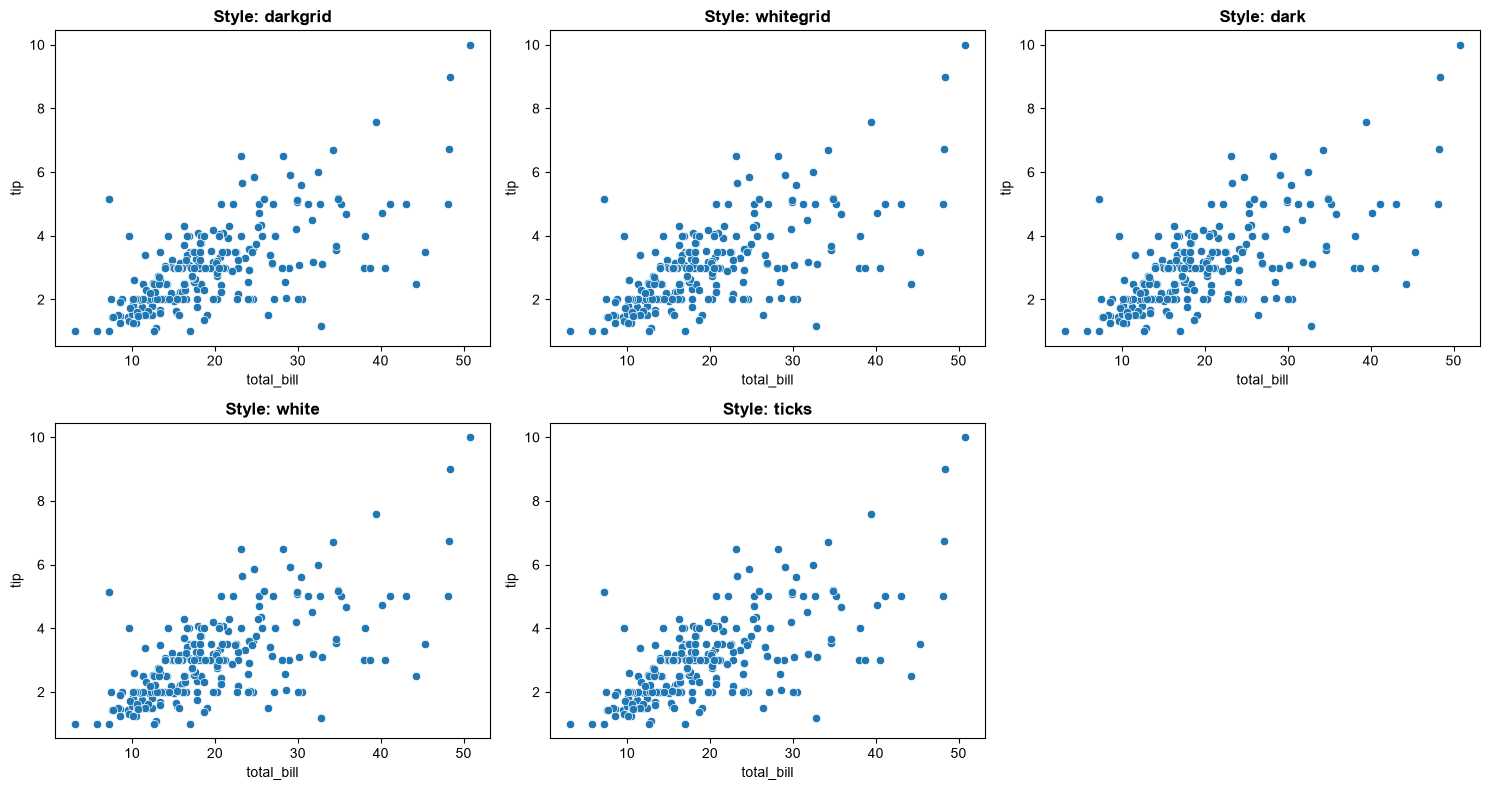

In [2]:
# Compare different styles
tips = sns.load_dataset('tips')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

for idx, style in enumerate(styles):
    ax = axes[idx//3, idx%3]
    sns.set_style(style)  # type: ignore[arg-type]
    sns.scatterplot(data=tips, x='total_bill', y='tip', ax=ax)
    ax.set_title(f'Style: {style}', fontweight='bold')
    
# Hide last subplot
axes[1, 2].axis('off')

plt.tight_layout()
save_fig('../exports/09_styling/seaborn_styles.png')
plt.show()

## 2️⃣ Color Theory for Data Visualization

### **Three Palette Types:**

1. **Sequential** - Ordered data (low → high)
   - Use: Heatmaps, choropleth maps, ordered categories
   - Examples: `Blues`, `Greens`, `YlOrRd`

2. **Diverging** - Data with meaningful midpoint
   - Use: Correlation matrices, deviations from mean/zero
   - Examples: `RdBu`, `coolwarm`, `Spectral`

3. **Qualitative/Categorical** - Unordered categories
   - Use: Different groups with no inherent order
   - Examples: `Set1`, `Set2`, `Set3`, `Paired`, `tab10`

/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/4014121846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips.groupby('day')['total_bill'].sum().reset_index(),
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/4014121846.py:6: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.barplot(data=tips.groupby('day')['total_bill'].sum().reset_index(),
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/4014121846.py:18: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.countplot(data=tips, x='day', hue='time', palette=palette_qual, ax=axes[2])


✅ Plot saved to ../exports/09_styling/palette_types.png


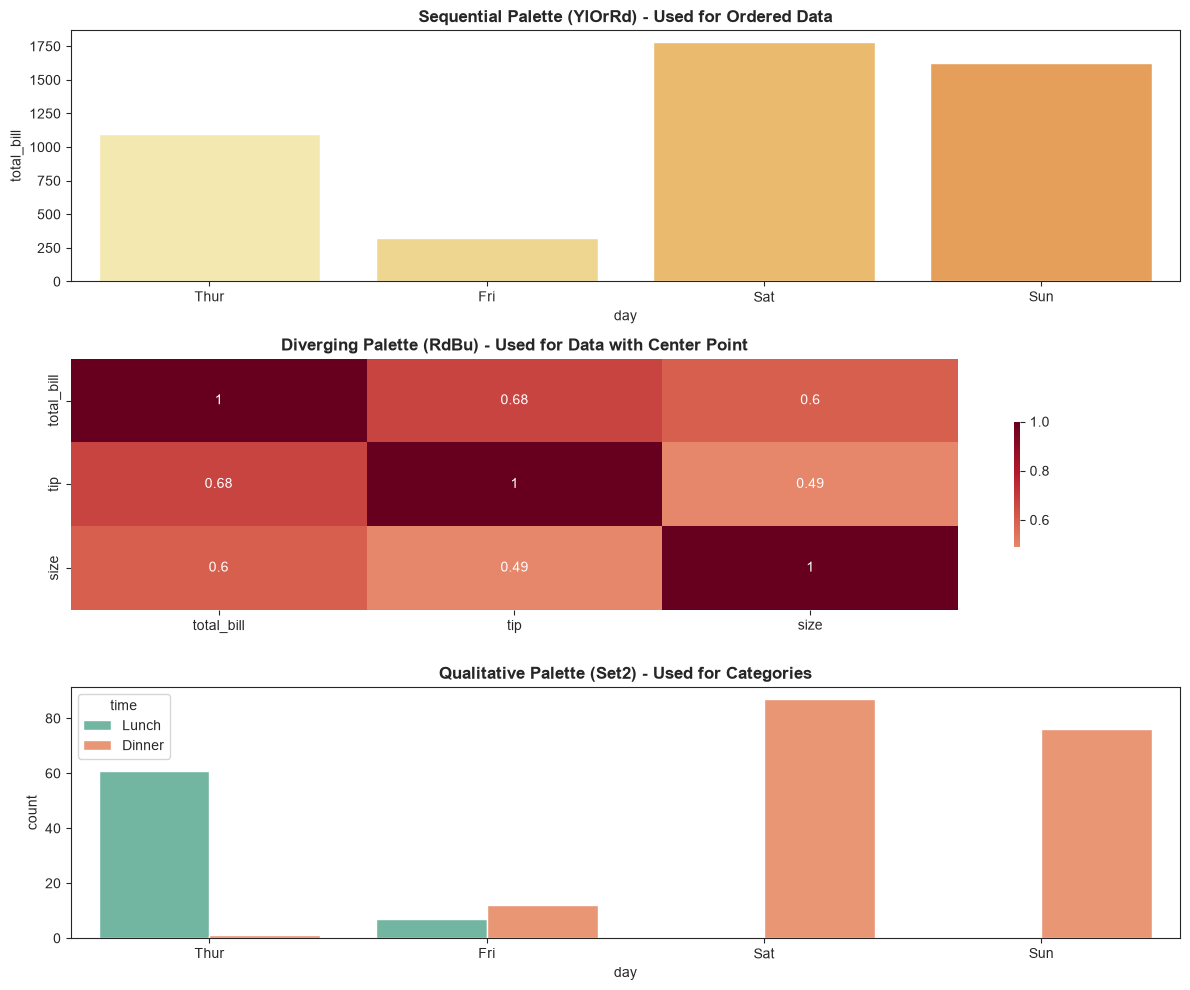

In [3]:
# Demonstrate all three palette types
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Sequential
palette_seq = sns.color_palette('YlOrRd', n_colors=8)
sns.barplot(data=tips.groupby('day')['total_bill'].sum().reset_index(), 
            x='day', y='total_bill', palette=palette_seq, ax=axes[0])
axes[0].set_title('Sequential Palette (YlOrRd) - Used for Ordered Data', fontweight='bold')

# Diverging
palette_div = sns.color_palette('RdBu_r', n_colors=8)
corr_data = tips[['total_bill', 'tip', 'size']].corr()  # type: ignore[call-arg]
sns.heatmap(corr_data, annot=True, cmap='RdBu_r', center=0, ax=axes[1], cbar_kws={'shrink': 0.5})
axes[1].set_title('Diverging Palette (RdBu) - Used for Data with Center Point', fontweight='bold')

# Qualitative
palette_qual = sns.color_palette('Set2')
sns.countplot(data=tips, x='day', hue='time', palette=palette_qual, ax=axes[2])
axes[2].set_title('Qualitative Palette (Set2) - Used for Categories', fontweight='bold')

plt.tight_layout()
save_fig('../exports/09_styling/palette_types.png')
plt.show()

## 3️⃣ Custom Color Palettes

Create custom palettes using:
- Hex codes
- RGB tuples
- Named colors
- Blend between colors

/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/2019028904.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tips, x='day', palette=custom_palette)
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/2019028904.py:6: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(data=tips, x='day', palette=custom_palette)


✅ Plot saved to ../exports/09_styling/custom_palette.png


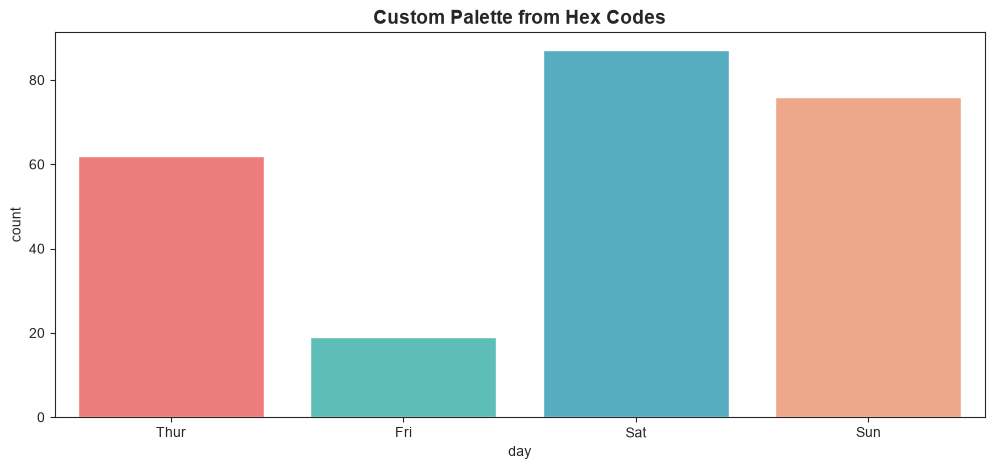

✅ Plot saved to ../exports/09_styling/blend_palette.png


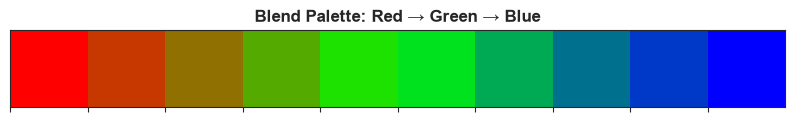

In [4]:
# Custom color palette from hex codes
custom_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
custom_palette = sns.color_palette(custom_colors)

plt.figure(figsize=(12, 5))
sns.countplot(data=tips, x='day', palette=custom_palette)
plt.title('Custom Palette from Hex Codes', fontweight='bold', fontsize=14)
save_fig('../exports/09_styling/custom_palette.png')
plt.show()

# Create a blend palette
blend_palette = sns.blend_palette(['#FF0000', '#00FF00', '#0000FF'], n_colors=10)
sns.palplot(blend_palette)
plt.title('Blend Palette: Red → Green → Blue', fontweight='bold')
save_fig('../exports/09_styling/blend_palette.png')
plt.show()

## 4️⃣ Color Dictionaries for Precise Mapping

Map specific categories to specific colors using dictionaries.

/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52847/4132570198.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', palette=day_colors)


✅ Plot saved to ../exports/09_styling/color_dictionary.png


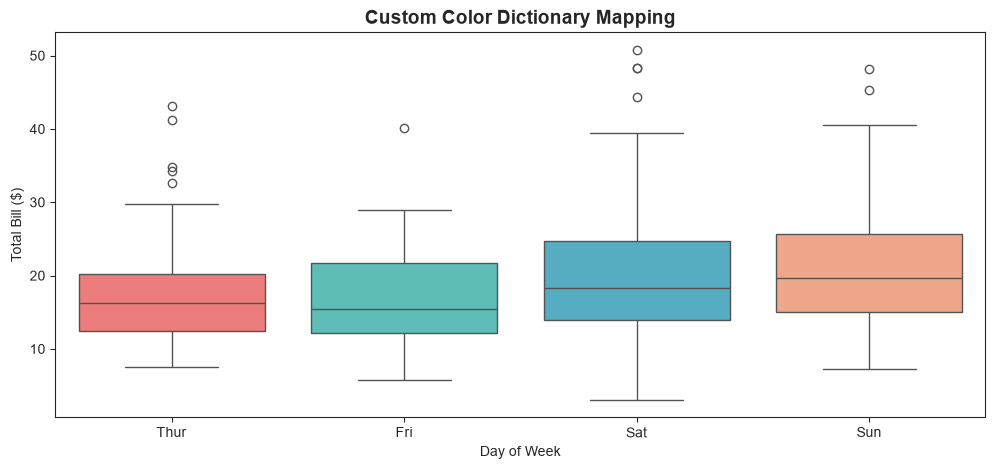

In [5]:
# Create custom color mapping
day_colors = {
    'Thur': '#FF6B6B',
    'Fri': '#4ECDC4',
    'Sat': '#45B7D1',
    'Sun': '#FFA07A'
}

plt.figure(figsize=(12, 5))
sns.boxplot(data=tips, x='day', y='total_bill', palette=day_colors)
plt.title('Custom Color Dictionary Mapping', fontweight='bold', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
save_fig('../exports/09_styling/color_dictionary.png')
plt.show()

## 🎯 Summary

### **Key Takeaways:**

1. **Styles:** Choose based on your medium (paper, notebook, talk, poster)
2. **Palette Types:**
   - **Sequential**: Ordered data (heatmaps, gradients)
   - **Diverging**: Data with meaningful center (correlations)
   - **Qualitative**: Categorical data (groups, categories)
3. **Custom Palettes:** Use hex codes, RGB, or `blend_palette()`
4. **Color Dictionaries:** Precise category-to-color mapping
5. **Consistency:** Use same colors for same categories across plots

### **Best Practices:**
- Use colorblind-friendly palettes when possibleUse sequential palettes for heatmaps
- Use diverging palettes for correlation matrices
- Limit colors to 5-7 for categorical data
- Ensure sufficient contrast for readability